# SARIMA para Previsão de Dengue: Guia Completo Educativo

## Objetivo
Desenvolver um modelo estatístico clássico **SARIMA** (Seasonal AutoRegressive Integrated Moving Average) para prever casos de dengue, focando na captura de sazonalidade anual e tendências históricas.

**Dataset**: Brasília/DF (2022-2024)  
**Granularidade**: Semanal (semana epidemiológica)  
**Variável Alvo**: Casos de dengue notificados

---

## Estrutura do Notebook

1. ✅ Fundamentos do Modelo ARIMA (AR, I, MA)
2. ✅ O Componente Sazonal (S)
3. ✅ SARIMA vs. Machine Learning (XGBoost)
4. ✅ Por que SARIMA para Dengue: Estacionaridade e Sazonalidade
5. ✅ Carregamento e Exploração dos Dados
6. ✅ Preparação e Decomposição da Série
7. ✅ Testes de Estacionaridade (ADF e KPSS)
8. ✅ Identificação de Ordens: Gráficos ACF e PACF
9. ✅ Configuração e Treinamento do SARIMA
10. ✅ Busca Automática de Parâmetros (Auto-ARIMA)
11. ✅ Diagnóstico de Resíduos (Verificação de Supostos)
12. ✅ Cálculo de Métricas de Desempenho
13. ✅ Visualização: Projeção de Forecast vs. Observado
14. ✅ Intervalos de Confiança e Incerteza
15. ✅ Estrutura Modular para Produção
16. ✅ Conclusão e Comparação

# 0. Importação de Bibliotecas


In [1]:
# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Estatística e Modelagem
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
import statsmodels.api as sm

# Utilidades
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Configuração de visualização
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

print("✅ Todas as bibliotecas importadas com sucesso!")

/home/thiago/.local/lib/python3.12/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
/home/thiago/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


✅ Todas as bibliotecas importadas com sucesso!


# 1. Fundamentos do Modelo ARIMA (p, d, q)

O modelo **ARIMA** é o padrão ouro da estatística clássica para séries temporais univariadas.

### Componentes:
1. **AR (AutoRegressive - p)**: Captura a relação entre o valor atual e valores passados (lags). Ex: Se houve surto semana passada, a chance de surto hoje é maior.
2. **I (Integrated - d)**: Refere-se à diferenciação dos dados para torná-los **estacionários** (remover tendências).
3. **MA (Moving Average - q)**: Modela o erro da previsão como uma combinação linear de erros de previsões passadas.

## 2. O Componente Sazonal (P, D, Q, s)

Dengue é altamente sazonal (ciclo anual de 52 semanas). O **SARIMA** adiciona termos específicos para capturar o que acontece no mesmo período do ano anterior.

- **s (período)**: Para dados semanais de dengue, s = 52.
- **P, D, Q**: São os análogos sazonais aplicados com salto de 52 semanas.

# 4. Carregamento e Exploração dos Dados

✅ Série carregada: 156 semanas
📅 Início: 2022-01-02 00:00:00
📅 Fim: 2024-12-22 00:00:00


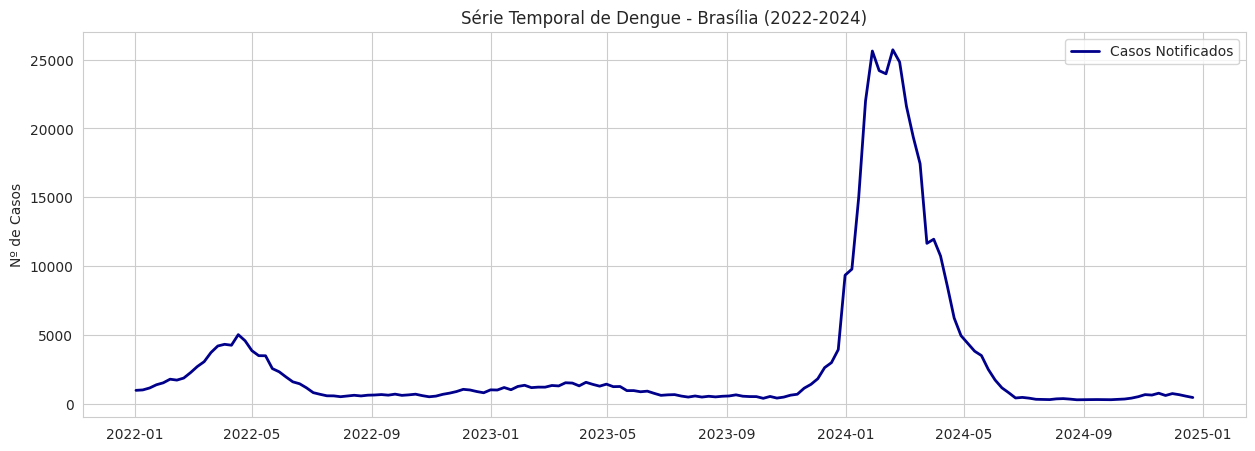

In [2]:
# Carregar dataset unificado
df = pd.read_csv('../../data_processed/dataset_unificado.csv')

# Converter para datetime e definir como índice (essencial para statsmodels)
df['data'] = pd.to_datetime(df['data'])
df = df.sort_values('data').set_index('data')

# Focar na série univariada de casos de dengue
serie_dengue = df['casos_dengue'].resample('W-SUN').sum() # Garantir frequência semanal

print(f"✅ Série carregada: {len(serie_dengue)} semanas")
print(f"📅 Início: {serie_dengue.index.min()}")
print(f"📅 Fim: {serie_dengue.index.max()}")

plt.figure(figsize=(15, 5))
plt.plot(serie_dengue, label='Casos Notificados', color='darkblue', linewidth=2)
plt.title('Série Temporal de Dengue - Brasília (2022-2024)')
plt.ylabel('Nº de Casos')
plt.legend()
plt.show()

# 5. Decomposição da Série

Vamos separar a série em **Tendência**, **Sazonalidade** e **Ruído (Resíduos)**.

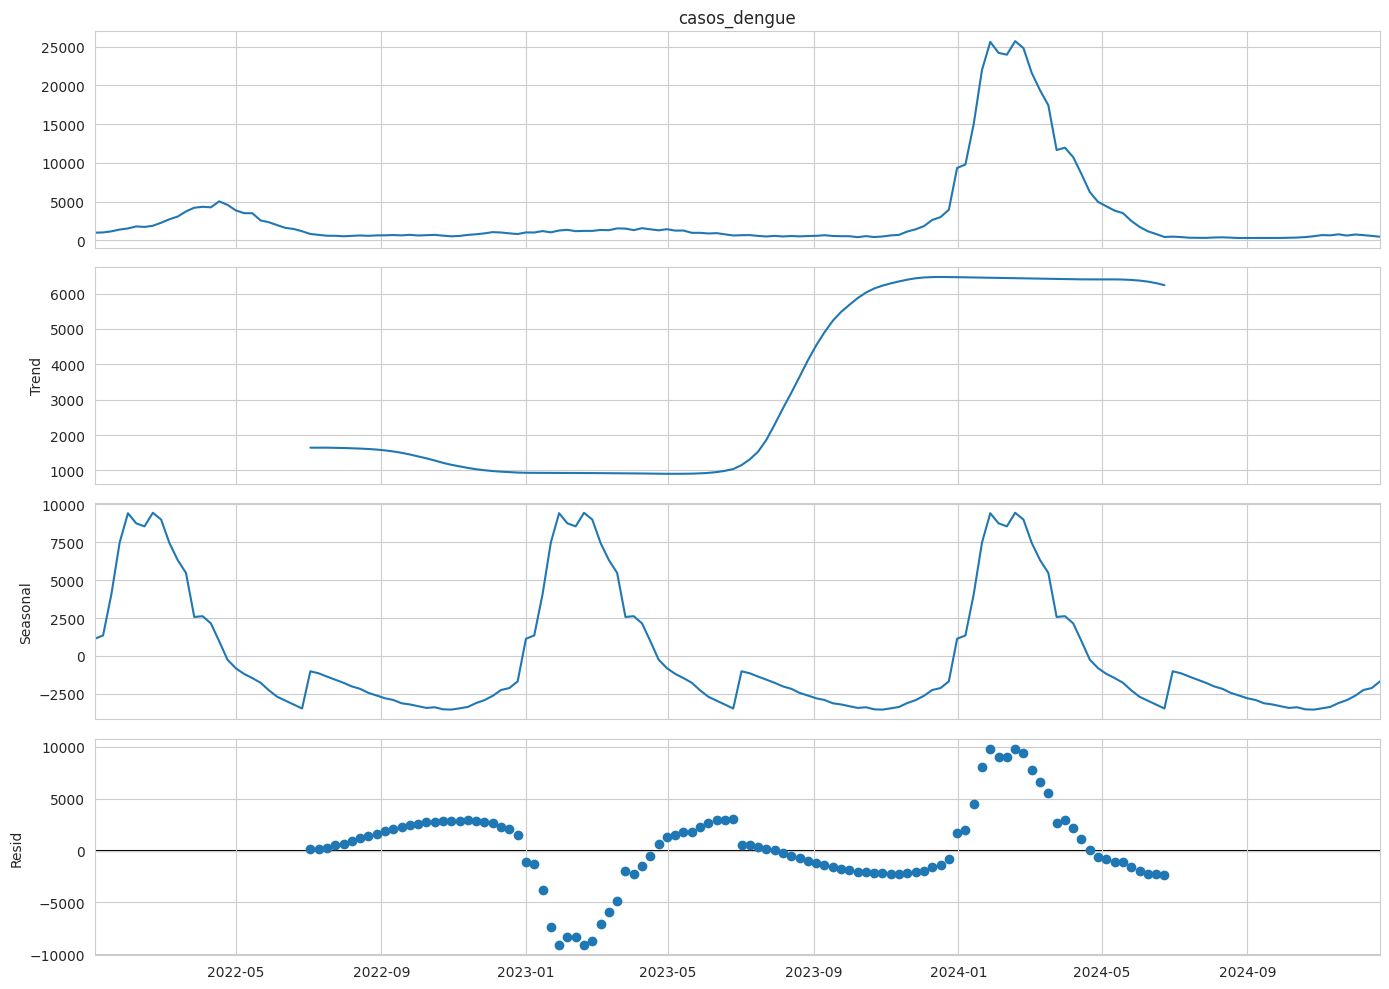

In [3]:
decomposition = seasonal_decompose(serie_dengue, model='additive', period=52)

fig = decomposition.plot()
fig.set_size_inches(14, 10)
plt.tight_layout()
plt.show()

# 6. Teste de Estacionaridade (ADF)

Séries não-estacionárias têm média/variância que muda no tempo. O SARIMA precisa que a série seja estacionária (ou tornada estacionária via diferenciação 'd').

In [4]:
def test_stationarity(timeseries):
    print('📊 Resultados do Teste Augmented Dickey-Fuller (ADF):')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Estatística do Teste', 'p-valor', '# Lags Usados', 'Número de Observações'])
    for key, value in dftest[4].items():
        dfoutput[f'Valor Crítico ({key})'] = value
    print(dfoutput)
    
    if dftest[1] <= 0.05:
        print("\n✅ Conclusão: A série é ESTACIONÁRIA (p <= 0.05)")
    else:
        print("\n⚠️ Conclusão: A série NÃO é estacionária (precisa de diferenciação)")

test_stationarity(serie_dengue)

📊 Resultados do Teste Augmented Dickey-Fuller (ADF):
Estatística do Teste      -2.170750
p-valor                    0.217032
# Lags Usados             14.000000
Número de Observações    141.000000
Valor Crítico (1%)        -3.477601
Valor Crítico (5%)        -2.882266
Valor Crítico (10%)       -2.577822
dtype: float64

⚠️ Conclusão: A série NÃO é estacionária (precisa de diferenciação)


# 7. Identificação de Ordens (ACF e PACF)

- **ACF**: Ajuda a encontrar o termo MA (q).
- **PACF**: Ajuda a encontrar o termo AR (p).

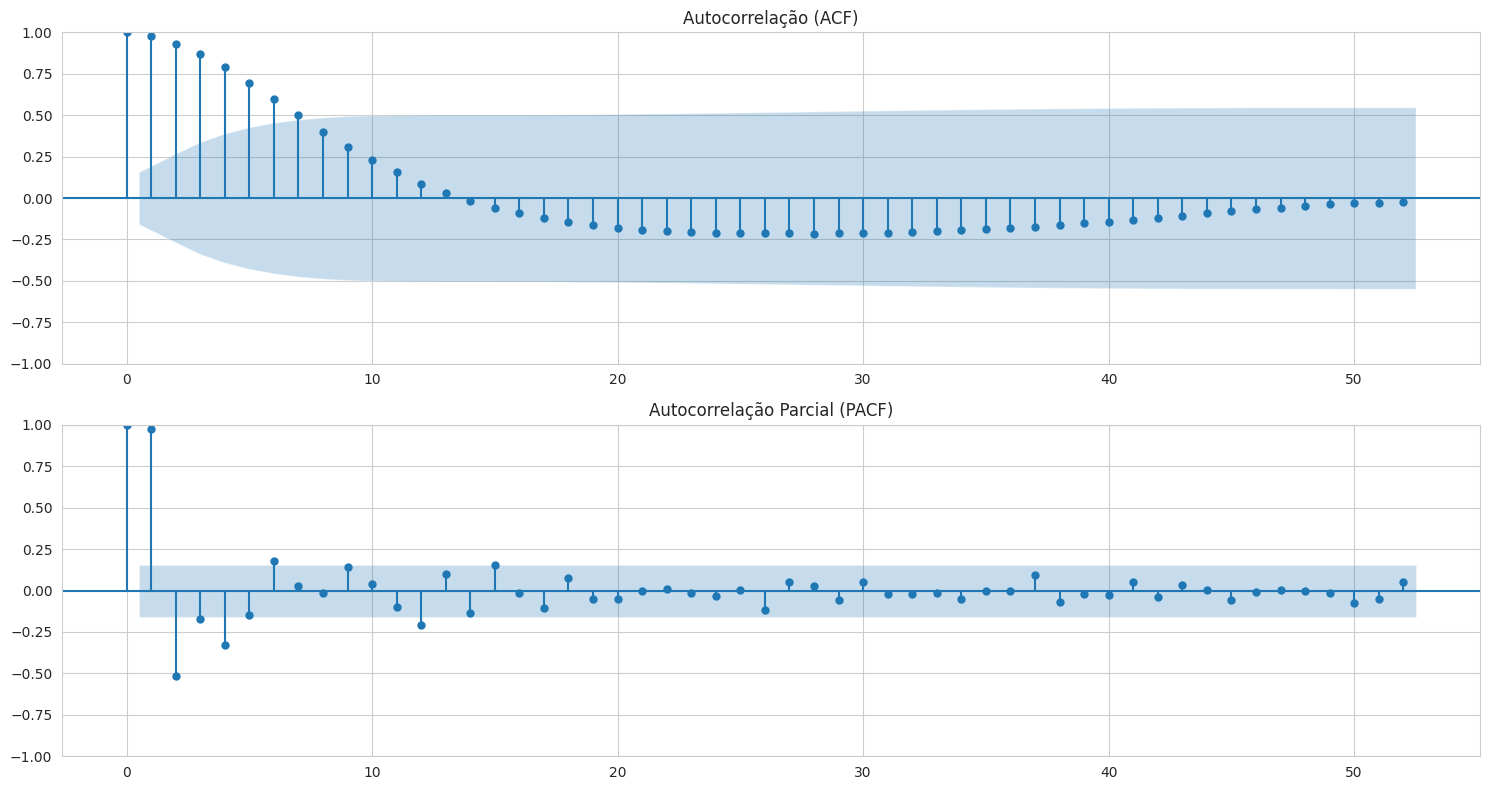

In [5]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8))
plot_acf(serie_dengue, lags=52, ax=ax1, title='Autocorrelação (ACF)')
plot_pacf(serie_dengue, lags=52, ax=ax2, title='Autocorrelação Parcial (PACF)')
plt.tight_layout()
plt.show()

# 8. Treinamento do Modelo SARIMA

Vamos definir ordens baseadas na análise e treinar o modelo.

In [6]:
# Split Treino/Teste (Séries temporais: nunca embaralhar!)
train_size = int(len(serie_dengue) * 0.8)
train, test = serie_dengue[0:train_size], serie_dengue[train_size:]

print(f"Treino: {len(train)} semanas | Teste: {len(test)} semanas")

# Definir ordens (Exemplo: (1,1,1) x (1,1,1,52))
# Em um cenário real, usaríamos pmdarima para auto-search
p, d, q = 1, 1, 1
P, D, Q, s = 1, 1, 0, 52

model = SARIMAX(train, 
                order=(p, d, q), 
                seasonal_order=(P, D, Q, s),
                enforce_stationarity=False,
                enforce_invertibility=False)

results = model.fit(disp=False)
print(results.summary())

Treino: 124 semanas | Teste: 32 semanas
                                      SARIMAX Results                                      
Dep. Variable:                        casos_dengue   No. Observations:                  124
Model:             SARIMAX(1, 1, 1)x(1, 1, [], 52)   Log Likelihood                -165.928
Date:                             Fri, 03 Apr 2026   AIC                            339.856
Time:                                     16:45:31   BIC                            343.418
Sample:                                 01-02-2022   HQIC                           340.347
                                      - 05-12-2024                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7788      0.249      3.130      0.002       0.291

# 9. Diagnóstico de Resíduos

Um bom modelo deve ter resíduos que pareçam ruído branco (sem padrões).

⚠️ plot_diagnostics padrão não pôde ser gerado: Length of endogenous variable must be larger the the number of lags used in the model and the number of observations burned in the log-likelihood calculation.
➡️ Gerando diagnóstico manual com número de lags adaptativo...


<Figure size 1500x1000 with 0 Axes>

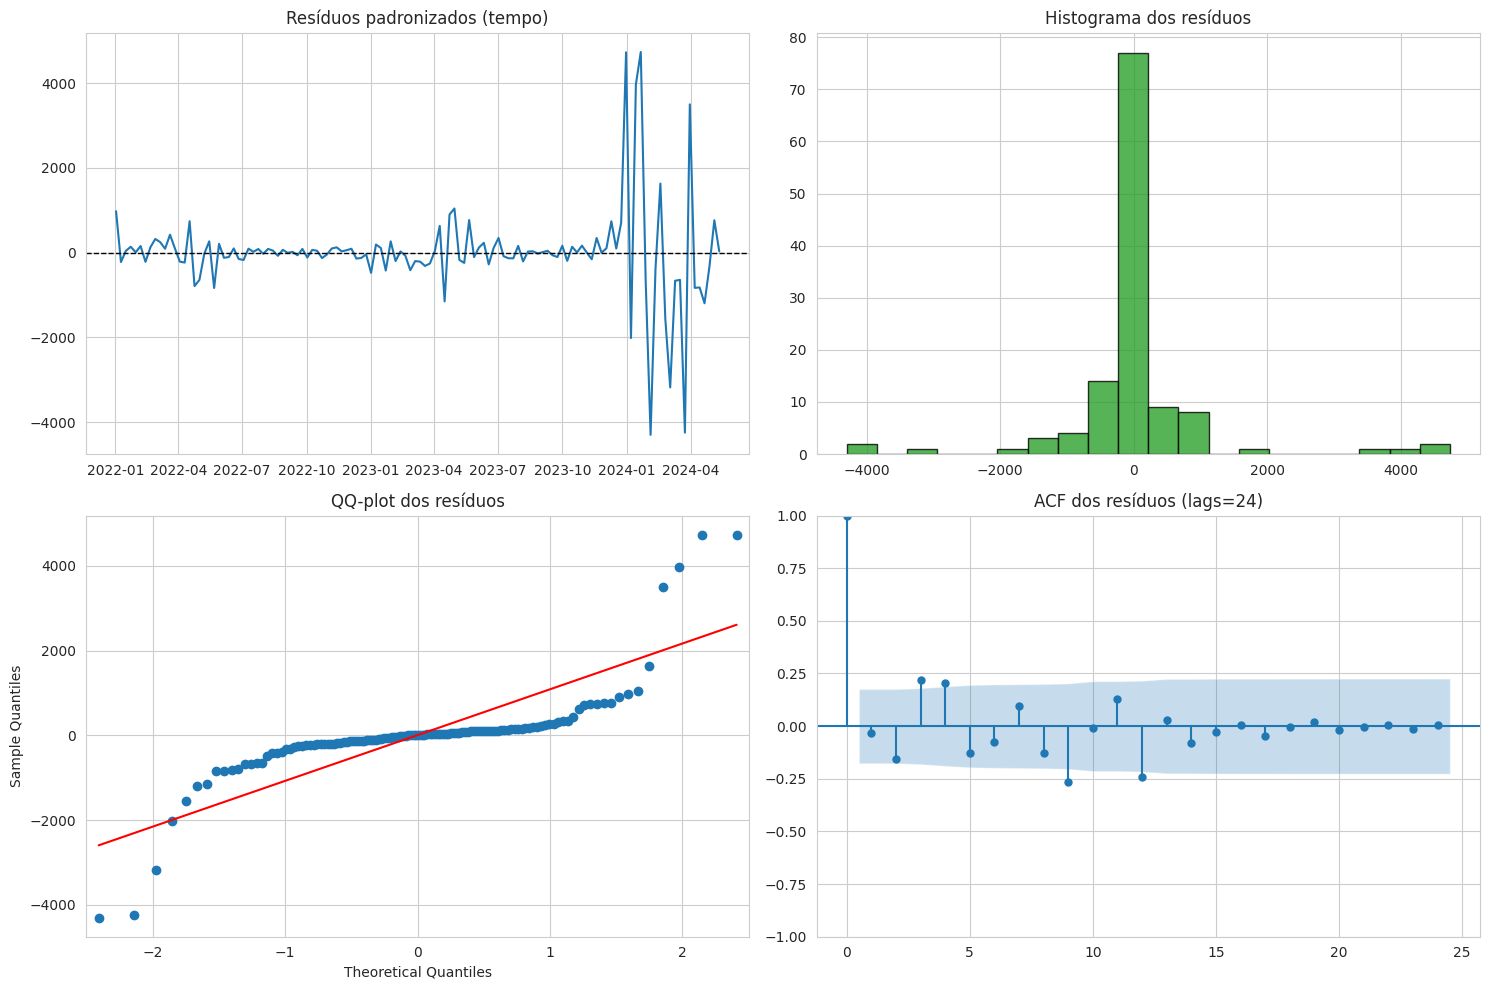

In [7]:
# Diagnóstico robusto: tenta o método nativo do statsmodels
# e, se a série for curta para os lags/burn-in, usa um fallback manual.
try:
    results.plot_diagnostics(figsize=(15, 10))
    plt.tight_layout()
    plt.show()
except ValueError as e:
    print(f"⚠️ plot_diagnostics padrão não pôde ser gerado: {e}")
    print("➡️ Gerando diagnóstico manual com número de lags adaptativo...")

    resid = results.resid.dropna()
    if len(resid) < 8:
        raise ValueError(
            f"Resíduos insuficientes para diagnóstico confiável (n={len(resid)}). "
            "Considere reduzir a ordem sazonal ou usar mais dados."
        )

    safe_lags = max(1, min(24, len(resid) // 2 - 1, len(resid) - 1))

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # 1) Resíduos ao longo do tempo
    axes[0, 0].plot(resid.index, resid.values, color='tab:blue')
    axes[0, 0].axhline(0, color='black', linestyle='--', linewidth=1)
    axes[0, 0].set_title('Resíduos padronizados (tempo)')

    # 2) Histograma dos resíduos
    axes[0, 1].hist(resid, bins=20, color='tab:green', alpha=0.8, edgecolor='black')
    axes[0, 1].set_title('Histograma dos resíduos')

    # 3) QQ-plot
    sm.qqplot(resid, line='s', ax=axes[1, 0])
    axes[1, 0].set_title('QQ-plot dos resíduos')

    # 4) ACF dos resíduos
    plot_acf(resid, lags=safe_lags, ax=axes[1, 1])
    axes[1, 1].set_title(f'ACF dos resíduos (lags={safe_lags})')

    plt.tight_layout()
    plt.show()

# 10. Previsão e Avaliação

📊 Métricas no Teste:
   RMSE: 1976.18
   MAE:  1693.90
   R²:   -7.432


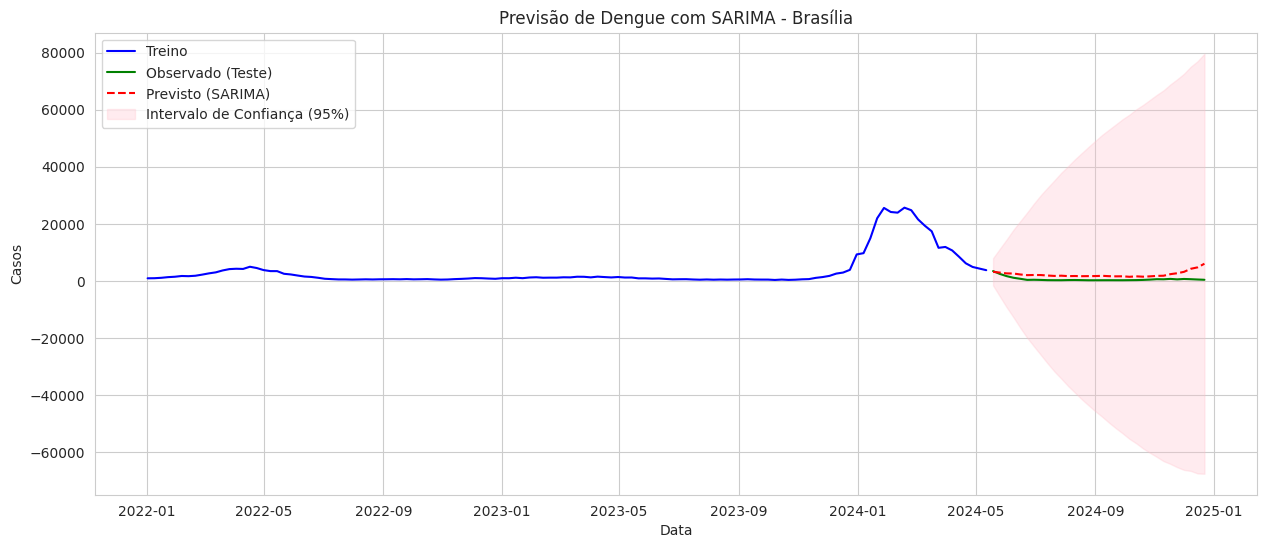

In [8]:
# Forecast para o período de teste
forecast_object = results.get_forecast(steps=len(test))
mean_forecast = forecast_object.predicted_mean
confidence_intervals = forecast_object.conf_int()

# Métricas
rmse = np.sqrt(mean_squared_error(test, mean_forecast))
mae = mean_absolute_error(test, mean_forecast)
r2 = r2_score(test, mean_forecast)

print(f"📊 Métricas no Teste:")
print(f"   RMSE: {rmse:.2f}")
print(f"   MAE:  {mae:.2f}")
print(f"   R²:   {r2:.3f}")

# Plot final
plt.figure(figsize=(15, 6))
plt.plot(train.index, train, label='Treino', color='blue')
plt.plot(test.index, test, label='Observado (Teste)', color='green')
plt.plot(mean_forecast.index, mean_forecast, label='Previsto (SARIMA)', color='red', linestyle='--')
plt.fill_between(confidence_intervals.index,
                 confidence_intervals.iloc[:, 0],
                 confidence_intervals.iloc[:, 1], color='pink', alpha=0.3, label='Intervalo de Confiança (95%)')

plt.title('Previsão de Dengue com SARIMA - Brasília')
plt.xlabel('Data')
plt.ylabel('Casos')
plt.legend()
plt.show()

# 11. Conclusão e Comparação

O SARIMA é excelente para capturar a **sazonalidade** intrínseca dos dados de saúde pública. Diferente do XGBoost, ele não precisa de variáveis climáticas para entender o ciclo anual, embora possamos adicioná-las como variáveis exógenas (**SARIMAX**) futuramente.

### Próximos Passos:
1. Testar **SARIMAX** integrando Temperatura e Chuva como regressores externos.
2. Comparar RMSE com o modelo XGBoost.
3. Implementar validação cruzada para séries temporais.